# Proyecto MDS7205 - Grafo de Conocimiento sobre PokeAPI

**Iniciativa de Datos e IA - Universidad de Chile**

Este reporte tecnico documenta el diseno, implementacion, consulta y analisis de un
grafo de conocimiento construido sobre **PokeAPI** (el esquema relacional completo de
Pokemon, 177 tablas CSV) modelado como **grafo de propiedades** y cargado en **Neo4j**.

## Motivacion

PokeAPI es una fuente rica y multi-relacional. La elegimos porque cumple el criterio
duro del enunciado (ser una red *interesante*) en tres frentes verificados empiricamente:

1. **Ciclos**: la efectividad de tipos es un grafo dirigido con ciclos reales
   (p.ej. `fighting -> ice -> flying -> fighting`) y self-loops (`ghost`, `dragon`).
2. **Recursion**: la evolucion es una jerarquia recursiva via la self-FK
   `evolves_from_species_id`.
3. **N-a-N navegable**: la compatibilidad de crianza por *egg groups* forma un grafo
   masivo con un componente conexo gigante.

El grafo final tiene del orden de **130 mil nodos** y **900 mil aristas**, dominadas por
la relacion `CAN_LEARN` (que movimientos puede aprender cada Pokemon), que ademas es un
**multigrafo con propiedades en la arista** (el caso canonico donde un grafo de
propiedades supera a RDF puro).


## Setup

Conexion al Neo4j levantado por `pipeline/load_all.sh` (puerto bolt 7687, sin auth).


In [1]:
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
%matplotlib inline

driver = GraphDatabase.driver("bolt://localhost:7687", auth=None)
def q(query):
    """Ejecuta Cypher y devuelve un DataFrame."""
    with driver.session() as s:
        return pd.DataFrame([r.data() for r in s.run(query)])
print("conectado:", q("RETURN 'Neo4j ' + toString(1) AS ok").iloc[0,0])

conectado: Neo4j 1


## 1. Modelo del grafo

El esquema relacional snowflake de PokeAPI se mapea a un grafo de propiedades: cada
tabla-entidad es un *label*, cada FK una relacion, y las tablas-puente con columnas
extra se vuelven **relaciones con propiedades** (`CAN_LEARN` carga nivel/metodo/version;
`HAS_TYPE` carga el slot; etc). Los encuentros se **reifican** como nodos `Encounter`
(relacion n-aria) y los nombres multilingues (11 idiomas) como nodos `Name`.

El pipeline de carga completo esta en `pipeline/` (`01_constraints` -> `05_scale`).


In [2]:
nodos = q("MATCH (n) UNWIND labels(n) AS l RETURN l AS label, count(*) AS nodos ORDER BY nodos DESC")
display(nodos)
print("TOTAL nodos:", f"{nodos['nodos'].sum():,}")

,label,nodos
0,Encounter,69427
1,Name,51988
2,Item,2176
3,PokemonForm,1578
4,Pokemon,1350
5,LocationArea,1246
6,Location,1096
7,Species,1025
8,Move,937
9,EvolutionCondition,546


TOTAL nodos: 131,879


In [3]:
aristas = q("MATCH ()-[r]->() RETURN type(r) AS relacion, count(*) AS aristas ORDER BY aristas DESC")
display(aristas)
print("TOTAL aristas:", f"{aristas['aristas'].sum():,}")

,relacion,aristas
0,CAN_LEARN,618511
1,COMPATIBLE,71232
2,HAS_ENCOUNTER,69427
3,AT_AREA,69427
4,HAS_NAME,51988
5,HAS_STAT,8100
6,HAS_ABILITY,2928
7,HAS_TYPE,2115
8,IS_SPECIES,1350
9,IN_EGG_GROUP,1304


TOTAL aristas: 902,000


## 2. Caracterizacion del grafo (EDA)

### 2.1 Distribucion del tamano de movepool
Cuantos movimientos distintos puede aprender cada Pokemon (formas default).


count    1025.0
mean       76.6
std        26.4
min         1.0
25%        61.0
50%        77.0
75%        92.0
max       375.0


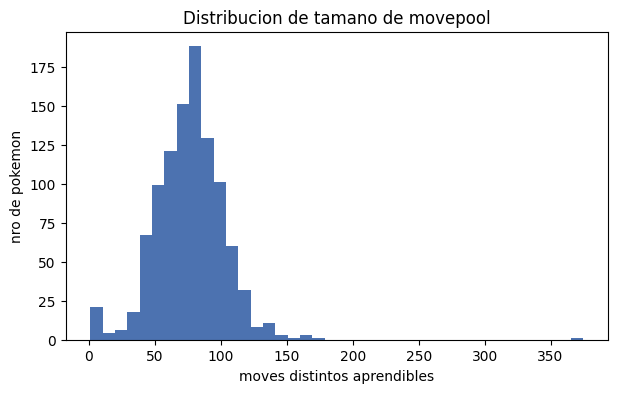

In [4]:
deg = q("""
MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)
RETURN p.identifier AS pokemon, count(DISTINCT m) AS moves
""")
print(deg["moves"].describe().round(1).to_string())
plt.figure(figsize=(7,4))
plt.hist(deg["moves"], bins=40, color="#4c72b0")
plt.xlabel("moves distintos aprendibles"); plt.ylabel("nro de pokemon")
plt.title("Distribucion de tamano de movepool"); plt.show()

### 2.2 Grafo de crianza (COMPATIBLE)
Dos especies son compatibles si comparten un *egg group* (excluyendo ditto y no-eggs).
Lo analizamos con networkx.


nodos: 873 | aristas: 71,232
componentes: 1 | mayor: 873 | densidad: 0.1871


grado medio: 163.2 | clustering medio: 0.883


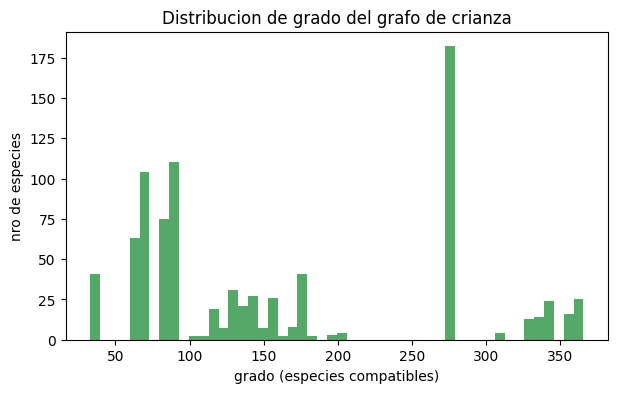

In [5]:
ed = q("MATCH (a:Species)-[:COMPATIBLE]->(b:Species) RETURN a.id AS a, b.id AS b")
G = nx.from_pandas_edgelist(ed, "a", "b")
comps = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"nodos: {G.number_of_nodes():,} | aristas: {G.number_of_edges():,}")
print(f"componentes: {len(comps)} | mayor: {len(comps[0])} | densidad: {nx.density(G):.4f}")
print(f"grado medio: {2*G.number_of_edges()/G.number_of_nodes():.1f} | clustering medio: {nx.average_clustering(G):.3f}")
plt.figure(figsize=(7,4))
plt.hist(list(dict(G.degree()).values()), bins=50, color="#55a868")
plt.xlabel("grado (especies compatibles)"); plt.ylabel("nro de especies")
plt.title("Distribucion de grado del grafo de crianza"); plt.show()

### 2.3 Distribucion de tipos primarios

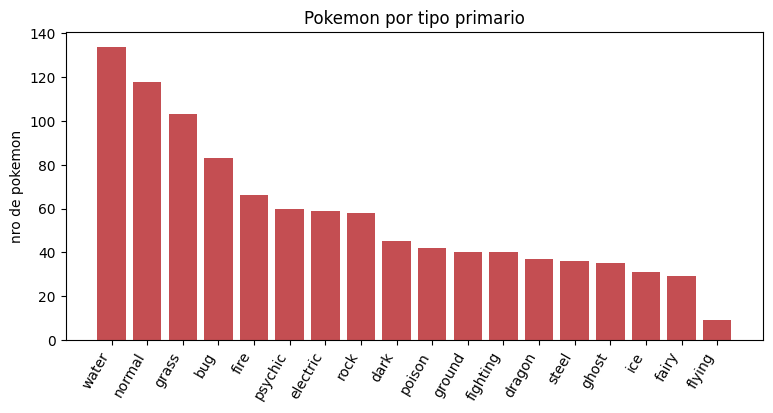

tipo,water,normal,grass,bug,fire,psychic,electric,rock,dark,poison,ground,fighting,dragon,steel,ghost,ice,fairy,flying
n,134,118,103,83,66,60,59,58,45,42,40,40,37,36,35,31,29,9


In [6]:
tipos = q("""
MATCH (p:Pokemon {is_default:true})-[r:HAS_TYPE {slot:1}]->(t:Type)
RETURN t.identifier AS tipo, count(*) AS n ORDER BY n DESC
""")
plt.figure(figsize=(9,4))
plt.bar(tipos["tipo"], tipos["n"], color="#c44e52")
plt.xticks(rotation=60, ha="right"); plt.ylabel("nro de pokemon")
plt.title("Pokemon por tipo primario"); plt.show()
display(tipos.set_index("tipo").T)

### 2.4 Capa multilingue
Cada entidad tiene nombres en 11 idiomas como nodos `Name`. Ejemplo: Pikachu.


In [7]:
q("""
MATCH (s:Species {identifier:'pikachu'})-[:HAS_NAME]->(n:Name)
RETURN n.lang AS lang_id, n.text AS nombre ORDER BY n.lang
""")

,lang_id,nombre
0,1,ピカチュウ
1,2,Pikachu
2,3,피카츄
3,4,皮卡丘
4,5,Pikachu
5,6,Pikachu
6,7,Pikachu
7,8,Pikachu
8,9,Pikachu
9,11,ピカチュウ


## 3. Consultas GQL (P1-P9)

Nueve consultas que explotan capacidades de grafo (ciclos, paths variables, comunidades,
centralidad) y que un `SELECT/JOIN` no resuelve limpio.

### P1 - Ciclos en el type chart (super-efectividad)

In [8]:
q("""
MATCH path = (t:Type)-[:SUPER_EFFECTIVE*3]->(t)
RETURN [n IN nodes(path) | n.identifier] AS ciclo LIMIT 10
""")

,ciclo
0,"[fighting, steel, fairy, fighting]"
1,"[fighting, dark, psychic, fighting]"
2,"[fighting, ice, flying, fighting]"
3,"[fighting, rock, flying, fighting]"
4,"[flying, grass, rock, flying]"
5,"[flying, fighting, ice, flying]"
6,"[flying, fighting, rock, flying]"
7,"[poison, grass, ground, poison]"
8,"[ground, electric, water, ground]"
9,"[ground, steel, ice, ground]"


### P2 - Linajes evolutivos completos (recursion)

In [9]:
q("""
MATCH p = (raiz:Species)-[:EVOLVES_TO*]->(hoja:Species)
WHERE NOT (:Species)-[:EVOLVES_TO]->(raiz) AND NOT (hoja)-[:EVOLVES_TO]->(:Species)
RETURN [n IN nodes(p) | n.identifier] AS linaje, length(p) AS saltos
ORDER BY saltos DESC, linaje LIMIT 10
""")

,linaje,saltos
0,"[abra, kadabra, alakazam]",2
1,"[applin, dipplin, hydrapple]",2
2,"[aron, lairon, aggron]",2
3,"[axew, fraxure, haxorus]",2
4,"[azurill, marill, azumarill]",2
5,"[bagon, shelgon, salamence]",2
6,"[beldum, metang, metagross]",2
7,"[bellsprout, weepinbell, victreebel]",2
8,"[blipbug, dottler, orbeetle]",2
9,"[bounsweet, steenee, tsareena]",2


### P3 - Condiciones de cada evolucion de Eevee (reificadas como nodos)
Cada fila de evolucion es un nodo `EvolutionCondition`. Leafeon y Glaceon traen varias
(piedra evolutiva o cercania a una roca), por eso se colectan todas en vez de quedarse con una.

In [10]:
q("""
MATCH (eevee:Species {identifier:'eevee'})-[:EVOLVES_TO]->(evo:Species)-[:EVOLVES_VIA]->(c:EvolutionCondition)
RETURN evo.identifier AS evolucion,
       collect({trigger:c.trigger, nivel:c.min_level, item:c.trigger_item,
                hora:c.time_of_day, felicidad:c.min_happiness, lugar:c.location}) AS condiciones
ORDER BY evolucion
""")

,evolucion,condiciones
0,espeon,"[{'item': None, 'hora': 'day', 'lugar': None, ..."
1,flareon,"[{'item': 82, 'hora': None, 'lugar': None, 'fe..."
2,glaceon,"[{'item': None, 'hora': None, 'lugar': 640, 'f..."
3,jolteon,"[{'item': 83, 'hora': None, 'lugar': None, 'fe..."
4,leafeon,"[{'item': 85, 'hora': None, 'lugar': None, 'fe..."
5,sylveon,"[{'item': None, 'hora': None, 'lugar': None, '..."
6,umbreon,"[{'item': None, 'hora': 'night', 'lugar': None..."
7,vaporeon,"[{'item': 84, 'hora': None, 'lugar': None, 'fe..."


### P4 - Comunidades de crianza (GDS Louvain)

In [11]:
with driver.session() as s: s.run("CALL gds.graph.drop('breeding', false)")
q("CALL gds.graph.project('breeding', 'Species', {COMPATIBLE: {orientation: 'UNDIRECTED'}})")
q("""
CALL gds.louvain.stream('breeding') YIELD nodeId, communityId
RETURN communityId, count(*) AS tam, collect(gds.util.asNode(nodeId).identifier)[..5] AS muestra
ORDER BY tam DESC LIMIT 10
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('breeding', false)"


,communityId,tam,muestra
0,18,278,"[rattata, raticate, ekans, arbok, pikachu]"
1,59,238,"[charmander, charmeleon, charizard, squirtle, ..."
2,87,173,"[abra, kadabra, alakazam, machop, machoke]"
3,35,114,"[caterpie, metapod, butterfree, weedle, kakuna]"
4,370,70,"[bulbasaur, ivysaur, venusaur, oddish, gloom]"
5,30,1,[nidoqueen]
6,29,1,[nidorina]
7,143,1,[articuno]
8,144,1,[zapdos]
9,131,1,[ditto]


### P5 - Especies puente en la crianza (GDS betweenness)

In [12]:
q("""
CALL gds.betweenness.stream('breeding') YIELD nodeId, score
RETURN gds.util.asNode(nodeId).identifier AS especie, round(score) AS score
ORDER BY score DESC LIMIT 10
""")

,especie,score
0,cufant,5844.0
1,fidough,5844.0
2,dachsbun,5844.0
3,copperajah,5844.0
4,araquanid,4940.0
5,surskit,4940.0
6,dewpider,4940.0
7,masquerain,4940.0
8,crustle,4484.0
9,dwebble,4484.0


### P6 - Centralidad ofensiva de tipos (GDS PageRank)

In [13]:
with driver.session() as s: s.run("CALL gds.graph.drop('typechart', false)")
q("CALL gds.graph.project('typechart', 'Type', {EFFECTIVENESS: {properties: 'factor'}})")
q("""
CALL gds.pageRank.stream('typechart', {relationshipWeightProperty: 'factor'}) YIELD nodeId, score
RETURN gds.util.asNode(nodeId).identifier AS tipo, round(score*1000)/1000 AS score
ORDER BY score DESC LIMIT 8
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('typechart', false)"


,tipo,score
0,ice,1.073
1,grass,1.065
2,rock,1.057
3,psychic,1.021
4,fighting,0.995
5,bug,0.992
6,ground,0.984
7,dragon,0.978


### P7 - Pares de Pokemon con mas moves en comun (proyeccion N-a-N)
Se deduplica el multigrafo a pares distintos antes del self-join.

In [14]:
q("""
MATCH (p:Pokemon)-[:CAN_LEARN]->(m:Move)
WHERE p.is_default
WITH DISTINCT m, p
WITH m, collect(p) AS aprendices
UNWIND aprendices AS a UNWIND aprendices AS b
WITH a, b WHERE a.id < b.id
WITH a, b, count(*) AS comunes WHERE comunes > 120
RETURN a.identifier AS pokemon_a, b.identifier AS pokemon_b, comunes
ORDER BY comunes DESC LIMIT 15
""")

,pokemon_a,pokemon_b,comunes
0,mew,arceus,164
1,mewtwo,mew,162
2,clefairy,clefable,158
3,jigglypuff,wigglytuff,146
4,wigglytuff,mew,144
5,clefable,mew,143
6,clefairy,mew,138
7,jigglypuff,mew,138
8,mew,gallade,135
9,chansey,blissey,133


### P8 - Areas con mas biodiversidad (encuentros reificados)

In [15]:
q("""
MATCH (la:LocationArea)<-[:AT_AREA]-(:Encounter)<-[:HAS_ENCOUNTER]-(p:Pokemon)-[:IS_SPECIES]->(s:Species)
WITH la, count(DISTINCT s) AS biodiversidad
RETURN la.identifier AS area, biodiversidad ORDER BY biodiversidad DESC LIMIT 12
""")

,area,biodiversidad
0,NaN,45
1,elite-four-defeated,45
2,NaN,44
3,NaN,44
4,NaN,42
5,1f,42
6,NaN,41
7,NaN,41
8,NaN,39
9,NaN,38


### P9 - Salto de stats en cada paso evolutivo (recursion + agregacion)

In [16]:
q("""
MATCH (a:Species)-[:EVOLVES_TO]->(b:Species)
MATCH (pa:Pokemon {is_default:true})-[:IS_SPECIES]->(a)
MATCH (pb:Pokemon {is_default:true})-[:IS_SPECIES]->(b)
MATCH (pa)-[s1:HAS_STAT]->(st:Stat)<-[s2:HAS_STAT]-(pb)
WITH a.identifier AS de, b.identifier AS hacia, sum(s2.base_stat - s1.base_stat) AS delta
RETURN de, hacia, delta ORDER BY delta DESC LIMIT 12
""")

,de,hacia,delta
0,feebas,milotic,340
1,magikarp,gyarados,340
2,meltan,melmetal,300
3,wimpod,golisopod,300
4,noibat,noivern,290
5,snom,frosmoth,290
6,cosmoem,lunala,280
7,cosmoem,solgaleo,280
8,charcadet,ceruledge,270
9,charcadet,armarouge,270


## 4. Machine Learning basico

### 4.1 Clasificacion de tipo primario
Predecir el tipo primario (18 clases) desde 6 stats base + conteo de moves por tipo.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

stats = q("""MATCH (p:Pokemon {is_default:true})-[r:HAS_STAT]->(s:Stat)
RETURN p.id AS pokemon, s.identifier AS stat, r.base_stat AS v""").pivot_table(
    index="pokemon", columns="stat", values="v", fill_value=0)
movetypes = q("""MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)-[:MOVE_TYPE]->(t:Type)
WITH p, t, count(DISTINCT m) AS c
RETURN p.id AS pokemon, 'mt_' + t.identifier AS movetype, c""").pivot_table(
    index="pokemon", columns="movetype", values="c", fill_value=0)
label = q("""MATCH (p:Pokemon {is_default:true})-[r:HAS_TYPE {slot:1}]->(t:Type)
RETURN p.id AS pokemon, t.identifier AS tipo""").set_index("pokemon")["tipo"]

data = stats.join(movetypes, how="left").fillna(0).join(label, how="inner").dropna(subset=["tipo"])
y = data["tipo"]; Xm = data.drop(columns="tipo")
clf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
scores = cross_val_score(clf, Xm, y, cv=cv)
stat_cols = [c for c in Xm.columns if not c.startswith("mt_")]
scores_stats = cross_val_score(clf, Xm[stat_cols], y, cv=cv)
print(f"{Xm.shape[0]} pokemon, {Xm.shape[1]} features, {y.nunique()} clases")
print(f"accuracy 5-fold CV: {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"baseline (clase mayoritaria): {y.value_counts(normalize=True).max():.3f}")
print(f"accuracy solo con stats base: {scores_stats.mean():.3f}")

1025 pokemon, 24 features, 18 clases
accuracy 5-fold CV: 0.823 +/- 0.017
baseline (clase mayoritaria): 0.131
accuracy solo con stats base: 0.201


Hay que leer ese 0.82 con cuidado: se apoya casi entero en los conteos de moves por tipo.
Con solo las 6 stats base la accuracy cae a ~0.20, apenas sobre el baseline. Tiene sentido, un
pokemon de fuego aprende muchos moves de fuego (efecto STAB), asi que predecir el tipo desde el
movepool es en parte circular. La senal es real pero la tarea es mas facil de lo que el numero sugiere.


### 4.2 Link prediction de compatibilidad de crianza
Dos encuadres. (a) **Topologico**: con features de vecindario el AUC es ~1.0, pero esto es
**estructural** (COMPATIBLE es una union de cliques solapadas, una por egg group),
no un logro del modelo. (b) **Por atributos fenotipicos** (stats, tipo, generacion): la tarea
predictiva real, no trivial.


2a) topologico (cliques solapadas): AUC=1.000
2b) por atributos fenotipicos:     AUC=0.671


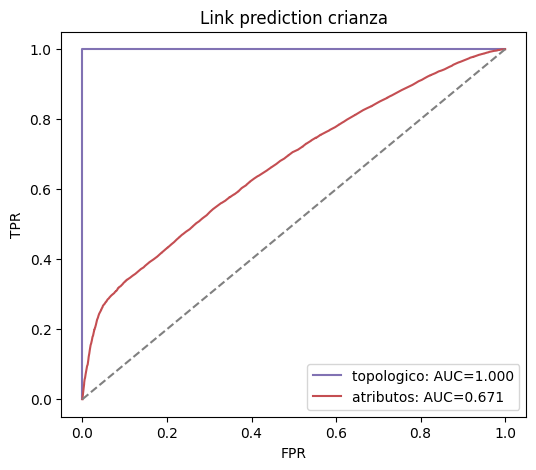

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(42)

nodes = sorted(set(ed.a) | set(ed.b))
edge_set = {(min(a,b), max(a,b)) for a,b in zip(ed.a, ed.b)}
pos = np.array(list(edge_set))
pos_tr, pos_te = train_test_split(pos, test_size=0.2, random_state=42)
adj = {n:set() for n in nodes}
for a,b in pos_tr: adj[a].add(b); adj[b].add(a)

def rand_neg(k):
    out=set(); nl=np.array(nodes)
    while len(out)<k:
        u,v = rng.choice(nl,2,replace=False); e=(int(min(u,v)),int(max(u,v)))
        if e not in edge_set: out.add(e)
    return np.array(list(out))
neg = rand_neg(len(pos)); neg_tr, neg_te = train_test_split(neg, test_size=0.2, random_state=42)
ytr = np.r_[np.ones(len(pos_tr)), np.zeros(len(neg_tr))]
yte = np.r_[np.ones(len(pos_te)), np.zeros(len(neg_te))]

def topo(pairs):
    r=[]
    for u,v in pairs:
        nu,nv=adj[u],adj[v]; cm=nu&nv; un=nu|nv
        r.append([len(cm), len(cm)/len(un) if un else 0,
                  sum(1/math.log(len(adj[w])) for w in cm if len(adj[w])>1), len(nu)*len(nv)])
    return np.array(r,dtype=float)
m1=RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1).fit(np.vstack([topo(pos_tr),topo(neg_tr)]),ytr)
p1=m1.predict_proba(np.vstack([topo(pos_te),topo(neg_te)]))[:,1]
auc1=roc_auc_score(yte,p1)

sf = q("""MATCH (s:Species)<-[:IS_SPECIES]-(p:Pokemon {is_default:true})-[r:HAS_STAT]->(st:Stat)
RETURN s.id AS sid, st.identifier AS stat, r.base_stat AS v""").pivot_table(index="sid",columns="stat",values="v",fill_value=0)
sm = q("""MATCH (s:Species) OPTIONAL MATCH (s)<-[:IS_SPECIES]-(:Pokemon {is_default:true})-[:HAS_TYPE {slot:1}]->(t:Type)
RETURN s.id AS sid, s.generation_id AS gen, t.identifier AS ptype""").set_index("sid")
def attr(pairs):
    r=[]
    for u,v in pairs:
        if u not in sf.index or v not in sf.index: r.append([0.0]*(sf.shape[1]+2)); continue
        d=list(np.abs(sf.loc[u].values-sf.loc[v].values))
        st=1.0 if (pd.notna(sm.loc[u,'ptype']) and sm.loc[u,'ptype']==sm.loc[v,'ptype']) else 0.0
        sg=1.0 if sm.loc[u,'gen']==sm.loc[v,'gen'] else 0.0
        r.append(d+[st,sg])
    return np.array(r,dtype=float)
m2=RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1).fit(np.vstack([attr(pos_tr),attr(neg_tr)]),ytr)
p2=m2.predict_proba(np.vstack([attr(pos_te),attr(neg_te)]))[:,1]
auc2=roc_auc_score(yte,p2)
print(f"2a) topologico (cliques solapadas): AUC={auc1:.3f}")
print(f"2b) por atributos fenotipicos:     AUC={auc2:.3f}")
plt.figure(figsize=(6,5))
for p,a,l,c in [(p1,auc1,'topologico','#8172b3'),(p2,auc2,'atributos','#c44e52')]:
    fpr,tpr,_=roc_curve(yte,p); plt.plot(fpr,tpr,color=c,label=f"{l}: AUC={a:.3f}")
plt.plot([0,1],[0,1],'--',color='gray'); plt.legend(loc='lower right')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Link prediction crianza"); plt.show()

## 5. Conclusiones

PokeAPI resulto un grafo de conocimiento genuino: cumple el criterio duro del enunciado (N-a-N
navegable, ciclos, recursion), todo verificado contra los datos, con del orden de 130 mil nodos
y 900 mil aristas. Los conteos exactos estan en la seccion 1.

El grafo de propiedades fue la eleccion correcta. `CAN_LEARN` carga propiedades en la arista y es
un multigrafo (el mismo par pokemon-move se repite por version y metodo), algo que en RDF puro
obligaria a reificar. Las consultas P1-P9 se apoyan en esa estructura: ciclos del type chart,
paths evolutivos, comunidades y centralidad de crianza, proyecciones N-a-N de movesets.

Del ML salieron dos lecturas honestas. El grafo de crianza es una union de cliques solapadas (una
por egg group), asi que predecir enlaces por topologia da AUC ~1.0, pero eso describe el grafo, no
al modelo; preguntar lo no trivial, si dos especies pueden cruzarse mirando solo su fenotipo, baja
a AUC ~0.67. Y la clasificacion de tipo llega a ~0.82, pero buena parte de esa senal es el movepool
(efecto STAB): con solo las stats base cae a ~0.20. En ambos casos el numero vistoso esconde un
matiz que vale mas que el numero.


In [19]:
driver.close()
print("fin del reporte")

fin del reporte
